In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 

In [4]:
dataset = pd.read_csv("iris.csv")

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [12]:
encoder = LabelEncoder()
dataset['Species_Encoded'] = encoder.fit_transform(dataset['Species'],)

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               150 non-null    int64  
 1   SepalLengthCm    150 non-null    float64
 2   SepalWidthCm     150 non-null    float64
 3   PetalLengthCm    150 non-null    float64
 4   PetalWidthCm     150 non-null    float64
 5   Species          150 non-null    object 
 6   Species_Encoded  150 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 8.3+ KB


In [38]:
dataset.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Encoded
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667,1.000000
std,43.445368,0.828066,0.433594,1.764420,0.763161,0.819232
min,1.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,38.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,75.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,112.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,150.000000,7.900000,4.400000,6.900000,2.500000,2.000000


In [15]:
dataset['Species_Encoded'].head()

0    0
1    0
2    0
3    0
4    0
Name: Species_Encoded, dtype: int64

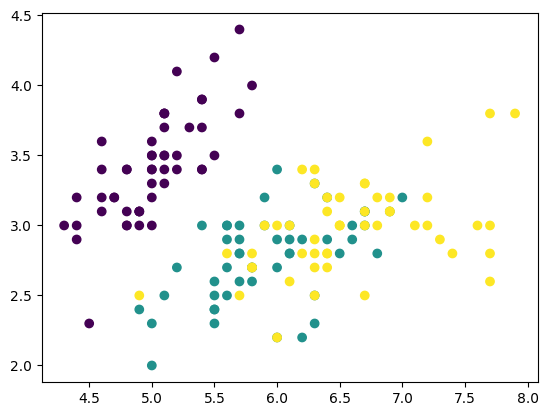

In [19]:
plt.scatter(dataset['SepalLengthCm'], dataset['SepalWidthCm'], c=dataset['Species_Encoded'])

Text(0, 0.5, 'Sepal Width in cm')

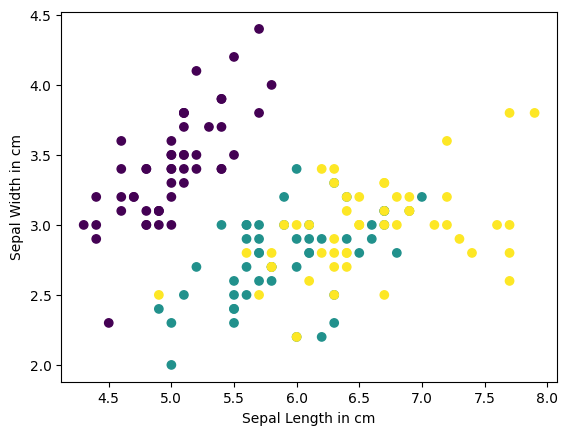

In [34]:
plt.scatter(dataset.iloc[:,1], dataset.iloc[:,2], c=dataset['Species_Encoded'])
plt.xlabel("Sepal Length in cm")
plt.ylabel("Sepal Width in cm")

Text(0, 0.5, 'Petal Width in cm')

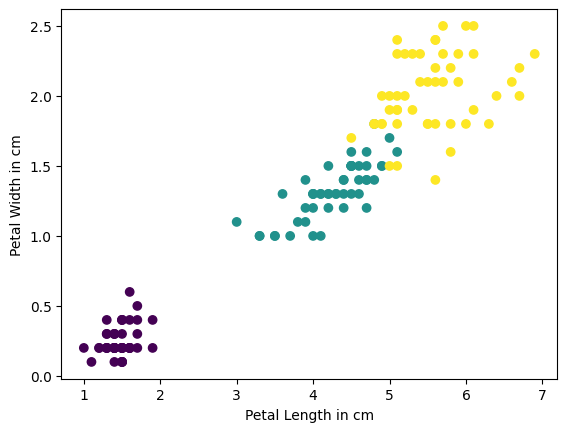

In [35]:
plt.scatter(dataset.iloc[:,3], dataset.iloc[:,4], c=dataset.iloc[:,6])
plt.xlabel("Petal Length in cm")
plt.ylabel("Petal Width in cm")

In [37]:
print(dataset.iloc[:5, :])

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Species_Encoded  
0                0  
1                0  
2                0  
3                0  
4                0  


Text(0, 0.5, 'Petal Length in cm')

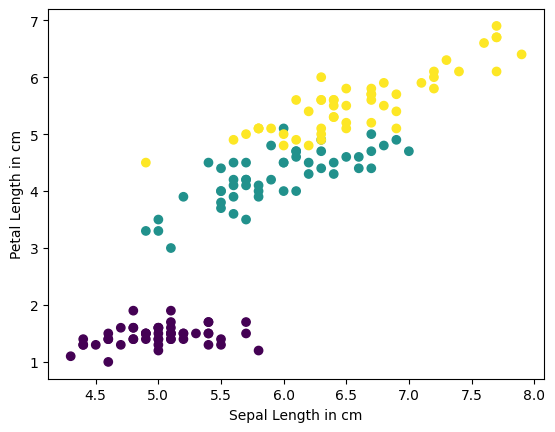

In [36]:
plt.scatter(dataset.iloc[:,1], dataset.iloc[:,3], c=dataset.iloc[:,6])
plt.xlabel("Sepal Length in cm")
plt.ylabel("Petal Length in cm")

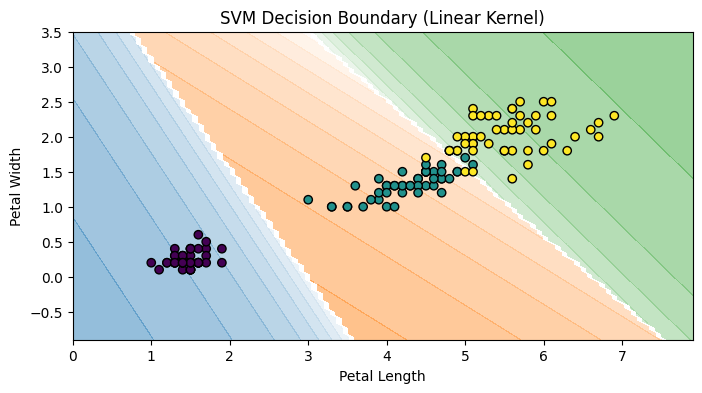

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder

# 1. Prepare Data and Train the Model (Your previous steps)
df = pd.read_csv('iris.csv')
X = df.iloc[:, [3,4]] 
y = LabelEncoder().fit_transform(df['Species'])

model = SVC(kernel='linear', C=1)
model.fit(X, y)


# 2. Setup the plot size
plt.figure(figsize=(8,4))

# 3. Draw the Decision Boundary (The Background / Street)
DecisionBoundaryDisplay.from_estimator(
    model,             # The trained SVM
    X,                 # Your 2D feature data
    response_method="decision_function", # Color the regions based on predictions
    #cmap=plt.cm.coolwarm,      # A nice color map (Blue/Red)
    alpha=0.5,                 # Make the background colors semi-transparent
    ax=plt.gca()               # Draw it on the current plot
)

# 4. Scatter the actual data points on top (Just like you did before!)
plt.scatter(
    x = X.iloc[:, 0], 
    y = X.iloc[:, 1], 
    c = y, 
    #cmap = plt.cm.coolwarm, # Match the dot colors to the background colors
    edgecolors = 'k'        # Put a black ring around dots so they stand out!
)

# 5. Add labels and show the masterpiece
plt.title("SVM Decision Boundary (Linear Kernel)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [60]:
print(X.iloc[:5,0])

0    1.4
1    1.4
2    1.3
3    1.5
4    1.4
Name: PetalLengthCm, dtype: float64


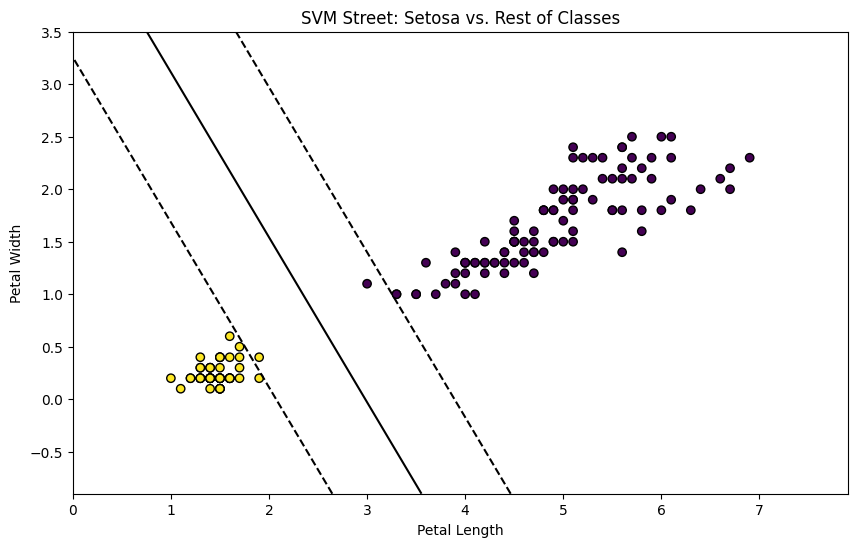

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Get your features (Let's use Petal Length and Width again)
X = dataset.iloc[:, [3,4]] 
y_original = dataset.iloc[:, 6]

# 2. THE TRICK: Create a Binary Target (1 if Setosa, 0 if anything else)
# Assuming Setosa was encoded as 0 in your dataset
y_binary = (y_original == 0).astype(int) 

# 3. Train the model on the new binary labels
model = SVC(kernel='linear', C=1.0)
model.fit(X, y_binary)

# 4. Setup the Plot
plt.figure(figsize=(10, 6))

# 6. Draw the Street (The Margins and Center Line)
DecisionBoundaryDisplay.from_estimator(
    model, X, 
    response_method="decision_function",
    plot_method="contour",
    levels=[-1, 0, 1], # Outer edges and center
    colors=['k', 'k', 'k'], 
    linestyles=['--', '-', '--'], 
    ax=plt.gca()
)

# 7. Scatter the dots, colored by our new binary labels!
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_binary, edgecolors='k')

plt.title("SVM Street: Setosa vs. Rest of Classes")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [91]:
model.score(X, y_binary)

1.0

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [35]:
data = pd.read_csv('iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [62]:
X = data.iloc[:,[3,4]] # Selecting only Sepal Length and Width.
y = LabelEncoder().fit_transform(data['Species'])

In [63]:
y_bin = (y == 0).astype(int)

In [64]:
X.shape

(150, 2)

In [67]:
y_bin.shape

(150,)

In [68]:
X_train, X_test, y_bin_train, y_bin_test = train_test_split(X,y_bin, test_size = 0.2)

In [69]:
print(X_train.shape)
print(X_test.shape)
print(y_bin_train.shape)
print(y_bin_test.shape)

(120, 2)
(30, 2)
(120,)
(30,)


In [70]:
X_train.head()

,PetalLengthCm,PetalWidthCm
90,4.4,1.2
83,5.1,1.6
84,4.5,1.5
103,5.6,1.8
99,4.1,1.3


In [71]:
model = SVC(kernel='linear', C=1)

In [72]:
model.fit(X_train, y_bin_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [73]:
y_pred = model.predict(X_test)

In [74]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy is: {accuracy * 100:.2f}%")

Model Accuracy is: 36.67%


In [75]:
y_pred[:5]

array([0, 0, 0, 0, 0])

In [76]:
y_test[:5]

array([1, 0, 2, 1, 1])

In [77]:
from sklearn.inspection import DecisionBoundaryDisplay

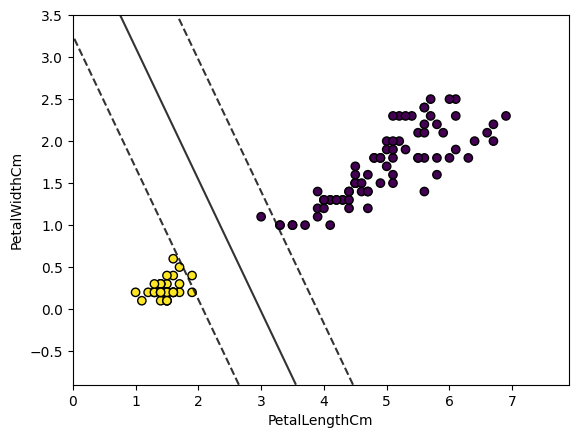

In [81]:
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_bin_train, edgecolors='k')

DecisionBoundaryDisplay.from_estimator(
    model, 
    X_train,
    plot_method="contour",
    response_method="decision_function",
    colors="black",
    levels=[-1,0,1],
    alpha=0.8,
    linestyles=["--","-","--"],
    ax=plt.gca()
)

In [82]:
## Decision Trees##

In [83]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(max_depth = 2, random_state= 1)